In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")

DATA_DIR = "/home/ankit/Development/MovieMate/Data/"

In [2]:
title_basics = pd.read_csv(f"{DATA_DIR}title.basics.tsv.gz", sep='\t',na_values="\\N",usecols=['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres'], low_memory=False)

title_ratings = pd.read_csv(f"{DATA_DIR}title.ratings.tsv.gz", sep='\t',na_values="\\N",usecols=['tconst', 'averageRating', 'numVotes'], low_memory=False)

title_principals = pd.read_csv(f"{DATA_DIR}title.principals.tsv.gz", sep='\t',na_values="\\N",usecols=['tconst', 'ordering', 'nconst', 'category', 'job', 'characters'], low_memory=False)

name_basics = pd.read_csv(f"{DATA_DIR}name.basics.tsv.gz", sep='\t',na_values="\\N",usecols=['nconst', 'primaryName', 'birthYear', 'deathYear', 'primaryProfession', 'knownForTitles'], low_memory=False)

print("title_basics: ", title_basics.shape)
print("title_ratings: ", title_ratings.shape)
print("title_principals: ", title_principals.shape)
print("name_basics: ", name_basics.shape)

title_basics:  (12373014, 9)
title_ratings:  (1650357, 3)
title_principals:  (98486993, 6)
name_basics:  (15175268, 6)


In [3]:
def audit(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print(df.head(3))
    print("\nMissing %")
    print((df.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))
    print("\nDtypes")
    print(df.dtypes)
audit(title_basics, "title_basics")
audit(title_ratings, "title_ratings")
audit(title_principals, "title_principals")
audit(name_basics, "name_basics")


title_basics
------------
      tconst titleType            primaryTitle           originalTitle  \
0  tt0000001     short              Carmencita              Carmencita   
1  tt0000002     short  Le clown et ses chiens  Le clown et ses chiens   
2  tt0000003     short            Poor Pierrot          Pauvre Pierrot   

   isAdult  startYear  endYear runtimeMinutes                    genres  
0        0     1894.0      NaN              1         Documentary,Short  
1        0     1892.0      NaN              5           Animation,Short  
2        0     1892.0      NaN              5  Animation,Comedy,Romance  

Missing %
endYear           98.75
runtimeMinutes    64.06
startYear         11.78
genres             4.32
tconst             0.00
isAdult            0.00
originalTitle      0.00
primaryTitle       0.00
titleType          0.00
dtype: float64

Dtypes
tconst                str
titleType             str
primaryTitle          str
originalTitle         str
isAdult             int64


In [4]:
# Data quality: duplicates and placeholder checks
print("Duplicate rows")
print("title_basics:", title_basics.duplicated().sum())
print("title_ratings:", title_ratings.duplicated().sum())
print("title_principals:", title_principals.duplicated().sum())
print("name_basics:", name_basics.duplicated().sum())

print("\nDuplicate IDs")
print("title_basics duplicate tconst:", title_basics["tconst"].duplicated().sum())
print("title_ratings duplicate tconst:", title_ratings["tconst"].duplicated().sum())
print("name_basics duplicate nconst:", name_basics["nconst"].duplicated().sum())

# Placeholder sanity check after na_values conversion
placeholder_counts = {
    "title_basics has literal \\N": (title_basics.astype(str) == "\\N").sum().sum(),
    "title_ratings has literal \\N": (title_ratings.astype(str) == "\\N").sum().sum(),
    "title_principals has literal \\N": (title_principals.astype(str) == "\\N").sum().sum(),
    "name_basics has literal \\N": (name_basics.astype(str) == "\\N").sum().sum(),
}
print("\nPlaceholder checks:")
print(placeholder_counts)

Duplicate rows
title_basics: 0
title_ratings: 0
title_principals: 0
name_basics: 0

Duplicate IDs
title_basics duplicate tconst: 0
title_ratings duplicate tconst: 0
name_basics duplicate nconst: 0

Placeholder checks:
{'title_basics has literal \\N': np.int64(0), 'title_ratings has literal \\N': np.int64(0), 'title_principals has literal \\N': np.int64(0), 'name_basics has literal \\N': np.int64(0)}


Unique title types: 11
titleType
tvEpisode       9552562
short           1119997
movie            740913
video            323246
tvSeries         296376
tvMovie          154249
tvMiniSeries      68970
tvSpecial         57379
videoGame         48373
tvShort           10948
tvPilot               1
Name: count, dtype: int64


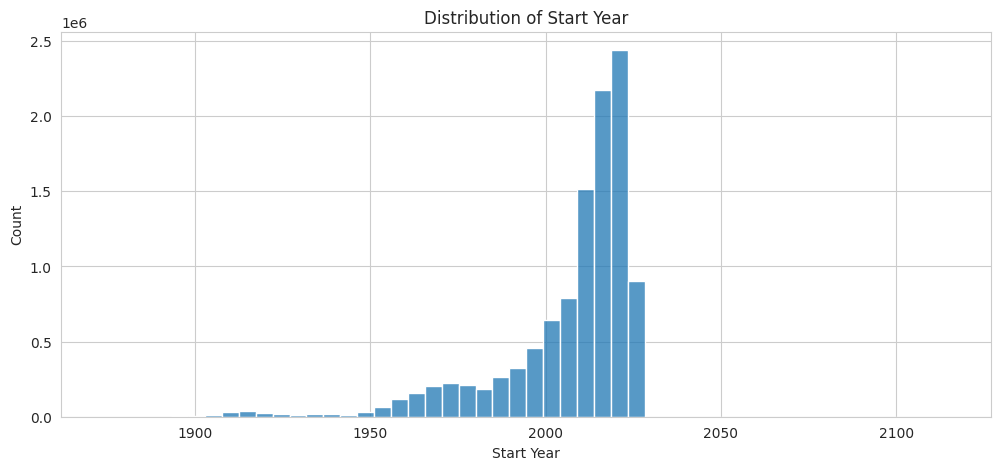

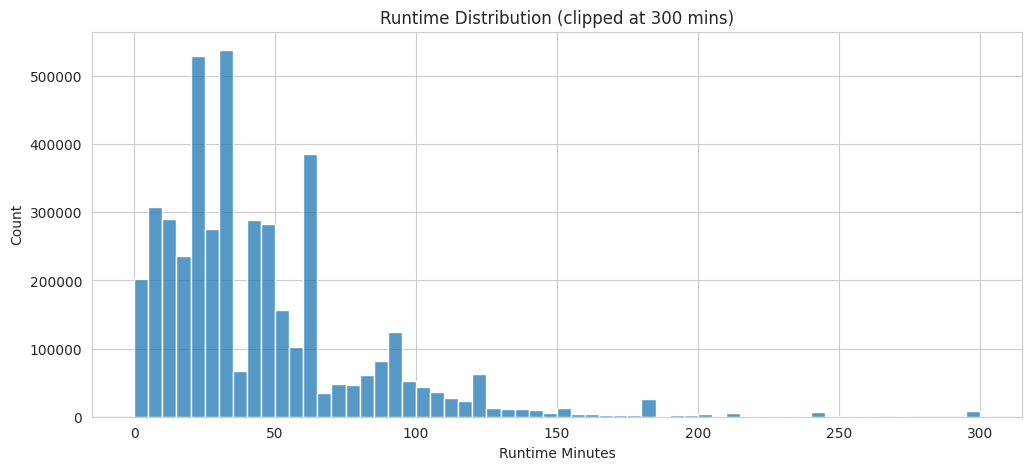

In [5]:
title_basics["startYear"] = pd.to_numeric(title_basics["startYear"], errors="coerce")
title_basics["endYear"] = pd.to_numeric(title_basics["endYear"], errors="coerce")
title_basics["runtimeMinutes"] = pd.to_numeric(title_basics["runtimeMinutes"], errors="coerce")

print("Unique title types:", title_basics["titleType"].nunique())
print(title_basics["titleType"].value_counts().head(15))

plt.figure(figsize=(12, 5))
sns.histplot(title_basics["startYear"].dropna(), bins=50)
plt.title("Distribution of Start Year")
plt.xlabel("Start Year")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(title_basics["runtimeMinutes"].dropna().clip(upper=300), bins=60)
plt.title("Runtime Distribution (clipped at 300 mins)")
plt.xlabel("Runtime Minutes")
plt.ylabel("Count")
plt.show()

genres
Drama          3453862
Comedy         2389867
Talk-Show      1530334
Short          1312471
News           1236410
Documentary    1175473
Romance        1140907
Family          908198
Reality-TV      695923
Animation       616105
Action          521737
Crime           519745
Adventure       479879
Game-Show       472855
Music           448738
Adult           402921
Sport           321302
Fantasy         276542
Mystery         266852
Horror          266628
Name: count, dtype: int64


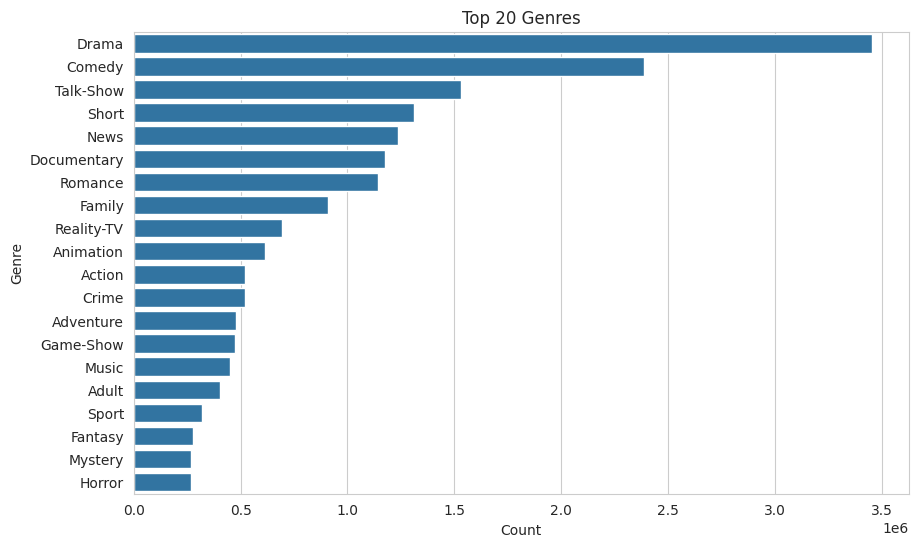

In [6]:
genres_long = (
    title_basics[["tconst", "genres"]]
    .dropna()
    .assign(genres=lambda df: df["genres"].str.split(","))
    .explode("genres")
)

top_genres = genres_long["genres"].value_counts().head(20)
print(top_genres)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 20 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

       averageRating      numVotes
count   1.650357e+06  1.650357e+06
mean    6.962741e+00  1.039157e+03
std     1.415231e+00  1.817805e+04
min     1.000000e+00  5.000000e+00
25%     6.200000e+00  1.200000e+01
50%     7.200000e+00  2.700000e+01
75%     7.900000e+00  1.030000e+02
max     1.000000e+01  3.168913e+06


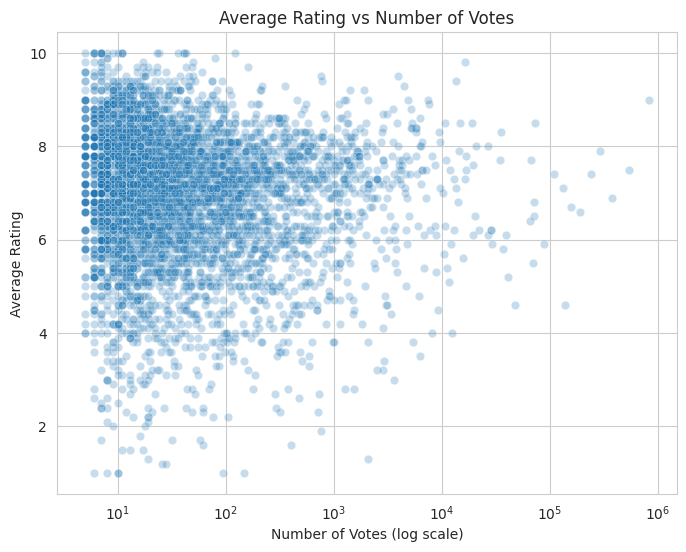

In [7]:
titles_with_ratings = title_basics.merge(title_ratings, on="tconst", how="left")
print(titles_with_ratings[["averageRating", "numVotes"]].describe())

plt.figure(figsize=(8,6))
sample_df = titles_with_ratings.dropna(subset=["averageRating", "numVotes"]).sample(n=min(5000,len(titles_with_ratings.dropna(subset=["averageRating", "numVotes"]))), random_state=42)
sns.scatterplot(data=sample_df, x="numVotes", y="averageRating", alpha=0.25)
plt.xscale("log")
plt.title("Average Rating vs Number of Votes")
plt.xlabel("Number of Votes (log scale)")
plt.ylabel("Average Rating")
plt.show()

In [8]:
#combining dataset for vector db prep

# We only want to deal with movies and TV shows so filtering them outb

ALLOWED_TYPES = ["movie", "tvSeries", "tvMovie", "tvMiniSeries", "tvSpecial"]

title_basics_filtered = title_basics[title_basics["titleType"].isin(ALLOWED_TYPES).copy()]
valid_tconst = set(title_basics_filtered["tconst"])

title_ratings_filtered = title_ratings[title_ratings["tconst"].isin(valid_tconst).copy()]
title_principals_filtered = title_principals[title_principals["tconst"].isin(valid_tconst).copy()]

print("title_basics_filtered: ", title_basics_filtered.shape)
print("title_ratings_filtered: ", title_ratings_filtered.shape)
print("title_principals_filtered: ", title_principals_filtered.shape)
print("Remaining title types:", title_basics_filtered["titleType"].value_counts())

title_basics_filtered:  (1317887, 9)
title_ratings_filtered:  (546139, 3)
title_principals_filtered:  (13013937, 6)
Remaining title types: titleType
movie           740913
tvSeries        296376
tvMovie         154249
tvMiniSeries     68970
tvSpecial        57379
Name: count, dtype: int64


In [9]:
# Keep top billed principals only to avoid very long text rows
principals_small = title_principals_filtered[title_principals_filtered["ordering"] <= 5].copy()

principals_small = principals_small.merge(
    name_basics[["nconst", "primaryName"]],
    on="nconst",
    how="left"
)

principals_small["person_role"] = (
    principals_small["category"].fillna("unknown") + ": " + principals_small["primaryName"].fillna("unknown")
)

people_summary = (
    principals_small.groupby("tconst")["person_role"]
    .apply(lambda s: " | ".join(s.astype(str).head(10)))
    .reset_index(name="people_summary")
)

vector_base = (
    title_basics_filtered
    .merge(title_ratings_filtered, on="tconst", how="left")
    .merge(people_summary, on="tconst", how="left")
)

vector_base["people_summary"] = vector_base["people_summary"].fillna("")
print("vector_base:", vector_base.shape)
vector_base.head(3)

vector_base: (1317887, 12)


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,people_summary
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,NaN,45.0,Romance,5.3,235.0,actress: Blanche Bayliss | actor: William Cour...
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,NaN,100.0,"Documentary,News,Sport",5.3,596.0,self: James J. Corbett | self: Bob Fitzsimmons...
2,tt0000502,movie,Bohemios,Bohemios,0,1905.0,NaN,100.0,NaN,3.5,26.0,actor: Antonio del Pozo | actor: El Mochuelo |...


In [10]:
vector_base.drop(columns=["originalTitle", "endYear"], inplace=True)

In [11]:
vector_base.head(5)
vector_base.to_csv(f"{DATA_DIR}ImdbData.csv", index=False)